In [5]:
#Importing necessary libraries and loading the dataset using Pandas File IO
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
df_IBM=pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn (1).csv')
print(df_IBM.head())
print('\n') #to add a new line after the output of head() function

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [6]:
#DataFrame Information
print(df_IBM.info())
print('\n') #to add a new line after the output of info() function


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
#DataFrame Information
print(df_IBM.info())
print('\n') #to add a new line after the output of info() function
#Using AI to check for missing values, data types, and potential scale issues in the dataset
# Check for missing values in each column (index)
print("Missing values per column:")
print(df_IBM.isnull().sum())
print('\n')

# Check data types for each column
print("Data types per column:")
print(df_IBM.dtypes)
print('\n')

# Check for columns with mixed types or potential scale issues
print("Summary statistics to check scales:")
print(df_IBM.describe())
print('\n')

# Check for unique values in object columns to see if there are unexpected types
for col in df_IBM.select_dtypes(include=['object']).columns:
    print(f"Unique values in {col}:")
    print(df_IBM[col].unique()[:10])  # Show first 10 unique values
    print('\n')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
#Define the association between the features and the target variable
# Assuming 'Churn' is the target variable
target = 'Churn'
features = [col for col in df_IBM.columns if col != target]

print(f"Target variable: {target}")
print(f"Feature variables: {features}")
print('\n')

# Separate features and target
X = df_IBM[features]
y = df_IBM[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print('\n')

# Check the distribution of the target
print("Target distribution:")
print(y.value_counts())
print('\n')

# For numeric features, show correlation with target (after encoding if needed)
# But since target is categorical, we can use point-biserial correlation for numeric features
numeric_features = X.select_dtypes(include=[np.number]).columns
if len(numeric_features) > 0:
    from scipy.stats import pointbiserialr
    print("Point-biserial correlations with target:")
    y_encoded = y.map({'Yes': 1, 'No': 0})
    for col in numeric_features:
        corr, p = pointbiserialr(X[col], y_encoded)
        print(f"{col}: {corr:.3f} (p={p:.3f})")
    print('\n')

# For categorical features, show chi-square test or just value counts
categorical_features = X.select_dtypes(include=['object']).columns
print("Categorical features associations (value counts by target):")
for col in categorical_features[:5]:  # Limit to first 5 to avoid too much output
    print(f"\n{col}:")
    print(pd.crosstab(X[col], y))

Target variable: Churn
Feature variables: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


Features shape: (7043, 20)
Target shape: (7043,)


Target distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


Point-biserial correlations with target:
SeniorCitizen: 0.151 (p=0.000)
tenure: -0.352 (p=0.000)
MonthlyCharges: 0.193 (p=0.000)


Categorical features associations (value counts by target):

customerID:
Churn       No  Yes
customerID         
0002-ORFBO   1    0
0003-MKNFE   1    0
0004-TLHLJ   0    1
0011-IGKFF   0    1
0013-EXCHZ   0    1
...         ..  ...
9987-LUTYD   1    0
9992-RRAMN   0    1
9992-UJOEL   1    0
9993-LHIEB   1    0
9995-HOTOH   1    0

[7043 rows x 2 columns]

gender:
Churn     No 

In [12]:
# Linear Regression Analysis for selected features and Churn
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, classification_report

print("\nLinear/Logistic Regression Analysis:")
print("=" * 50)

# Encode the target variable
y_encoded = y.map({'Yes': 1, 'No': 0})

for feature in selected_features:
    print(f"\nFeature: {feature}")
    X_feature = X[[feature]].copy()
    
    # Handle missing values
    X_feature = X_feature.fillna(X_feature.mean()) if feature in numeric_features else X_feature
    
    if feature in numeric_features:
        # Linear Regression
        lr = LinearRegression()
        lr.fit(X_feature, y_encoded)
        y_pred = lr.predict(X_feature)
        r2 = r2_score(y_encoded, y_pred)
        
        print(f"  Linear Regression:")
        print(f"    Coefficient: {lr.coef_[0]:.4f}")
        print(f"    Intercept: {lr.intercept_:.4f}")
        print(f"    R-squared: {r2:.4f}")
    
    else:
        # For categorical features, encode them
        le = LabelEncoder()
        X_encoded = le.fit_transform(X_feature[feature])
        X_encoded = X_encoded.reshape(-1, 1)
        
        # Linear Regression
        lr = LinearRegression()
        lr.fit(X_encoded, y_encoded)
        y_pred = lr.predict(X_encoded)
        r2 = r2_score(y_encoded, y_pred)
        
        print(f"  Linear Regression (encoded):")
        print(f"    Coefficient: {lr.coef_[0]:.4f}")
        print(f"    Intercept: {lr.intercept_:.4f}")
        print(f"    R-squared: {r2:.4f}")
    
    # Logistic Regression for binary classification
    if feature in numeric_features:
        X_feature_clean = X_feature.fillna(X_feature.mean())
    else:
        le = LabelEncoder()
        X_feature_clean = le.fit_transform(X_feature[feature]).reshape(-1, 1)
    
    log_reg = LogisticRegression(random_state=42, max_iter=1000)
    log_reg.fit(X_feature_clean, y_encoded)
    y_pred_log = log_reg.predict(X_feature_clean)
    
    # Calculate accuracy
    accuracy = (y_pred_log == y_encoded).mean()
    print(f"  Logistic Regression:")
    print(f"    Coefficient: {log_reg.coef_[0][0]:.4f}")
    print(f"    Intercept: {log_reg.intercept_[0]:.4f}")
    print(f"    Accuracy: {accuracy:.4f}")
    print(f"    Probability of Churn (feature value effect): {log_reg.coef_[0][0]:.4f}")


Linear/Logistic Regression Analysis:

Feature: PaymentMethod
  Linear Regression (encoded):
    Coefficient: 0.0443
    Intercept: 0.1957
    R-squared: 0.0115
  Logistic Regression:
    Coefficient: 0.2312
    Intercept: -1.3963
    Accuracy: 0.7346
    Probability of Churn (feature value effect): 0.2312

Feature: TotalCharges
  Linear Regression (encoded):
    Coefficient: 0.0000
    Intercept: 0.2543
    R-squared: 0.0002
  Logistic Regression:
    Coefficient: 0.0000
    Intercept: -1.0751
    Accuracy: 0.7346
    Probability of Churn (feature value effect): 0.0000

Feature: tenure
  Linear Regression:
    Coefficient: -0.0063
    Intercept: 0.4704
    R-squared: 0.1241
  Logistic Regression:
    Coefficient: -0.0388
    Intercept: 0.0274
    Accuracy: 0.7331
    Probability of Churn (feature value effect): -0.0388

Feature: Contract
  Linear Regression (encoded):
    Coefficient: -0.2101
    Intercept: 0.4104
    R-squared: 0.1574
  Logistic Regression:
    Coefficient: -1.6789
 


Multiple Linear Regression Analysis with All Features:

Model Performance:
  Training R²: 0.1734
  Testing R²: 0.1836
  Training RMSE: 0.4004
  Testing RMSE: 0.4021
  Training MAE: 0.3326
  Testing MAE: 0.3343

Feature Coefficients (sorted by importance):
         Feature  Coefficient
3       Contract    -0.130376
2         tenure    -0.073336
1   TotalCharges     0.033290
0  PaymentMethod    -0.008824

Intercept: 0.2632


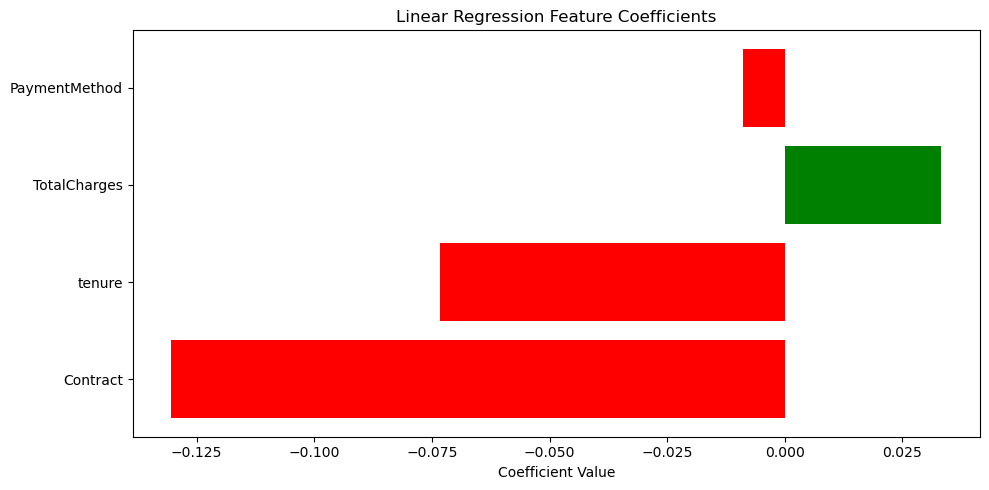


Predicted vs Actual (first 20 test samples):
    Actual  Predicted
0        1   0.439919
1        0   0.415927
2        0  -0.068258
3        1   0.506514
4        0  -0.039437
5        1   0.308469
6        0   0.064548
7        0  -0.037759
8        1  -0.007197
9        1   0.421750
10       0   0.424094
11       0   0.341376
12       0   0.179057
13       1   0.369304
14       0   0.420898
15       1   0.505568
16       1   0.461580
17       1   0.500856
18       0   0.347466
19       1   0.369892


In [2]:
# Tenure vs Churn (Box Plot)
df_plot = df_IBM.copy()
df_plot["TotalCharges"] = pd.to_numeric(df_plot["TotalCharges"], errors="coerce")
df_plot["TotalCharges"].fillna(df_plot["TotalCharges"].median(), inplace=True)
sns.set_style("whitegrid")
plt.figure(figsize=(6, 5))
sns.boxplot(x='Churn', y='tenure', data=df_plot, palette='Set2', width=0.6)
plt.title('Tenure by Churn Status', fontsize=12, fontweight='bold')
plt.ylabel('Months', fontsize=10, fontweight='bold')
plt.xlabel('Churn Status', fontsize=10, fontweight='bold')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

NameError: name 'df_IBM' is not defined

In [ ]:
# Contract Type vs Churn (Count Plot)
plt.figure(figsize=(6, 5))
sns.countplot(x='Contract', hue='Churn', data=df_plot, palette='Set2')
plt.title('Contract Type by Churn Status', fontsize=12, fontweight='bold')
plt.ylabel('Count', fontsize=10, fontweight='bold')
plt.xlabel('Contract Type', fontsize=10, fontweight='bold')
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.legend(title='Churn', labels=['No', 'Yes'], loc='upper right', fontsize=9)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

In [ ]:
# Monthly Charges vs Churn (Box Plot)
plt.figure(figsize=(6, 5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df_plot, palette='Set2', width=0.6)
plt.title('Monthly Charges by Churn Status', fontsize=12, fontweight='bold')
plt.ylabel('Charges ($)', fontsize=10, fontweight='bold')
plt.xlabel('Churn Status', fontsize=10, fontweight='bold')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

In [ ]:
# Total Charges vs Churn (Box Plot)
plt.figure(figsize=(6, 5))
sns.boxplot(x='Churn', y='TotalCharges', data=df_plot, palette='Set2', width=0.6)
plt.title('Total Charges by Churn Status', fontsize=12, fontweight='bold')
plt.ylabel('Charges ($)', fontsize=10, fontweight='bold')
plt.xlabel('Churn Status', fontsize=10, fontweight='bold')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# Visualization Summary and Insights
- Each variable is now visualized in a separate cell for clarity.
- Compare the patterns between 'No Churn' and 'Churn' to identify associations.
- Box plots (numeric): Show distribution, median, and outliers.
- Count plots (categorical): Show frequency of each category by churn status.

In [30]:
# Linear regression per variable (single-feature tests) for the 4 selected predictors
print("\nSingle-Feature Linear Regression Tests:")
print("="*60)

lr_features = ['tenure', 'Contract', 'MonthlyCharges', 'TotalCharges']

y_encoded = y.map({'Yes': 1, 'No': 0})

for feature in lr_features:
    print(f"\nFeature: {feature}")
    X_feat = X[[feature]].copy()

    # Handle missing values
    if feature in numeric_features:
        X_feat = X_feat.fillna(X_feat.mean())
    else:
        X_feat[feature] = X_feat[feature].fillna('Unknown')
        le = LabelEncoder()
        X_feat[feature] = le.fit_transform(X_feat[feature])

    # Fit linear regression
    lr = LinearRegression()
    lr.fit(X_feat, y_encoded)
    y_pred = lr.predict(X_feat)
    r2 = r2_score(y_encoded, y_pred)

    print(f"  Coefficient: {lr.coef_[0]:.4f}")
    print(f"  Intercept: {lr.intercept_:.4f}")
    print(f"  R²: {r2:.4f}")
    print(f"  Mean prediction (sample): {np.mean(y_pred):.4f}")


Single-Feature Linear Regression Tests:

Feature: tenure
  Coefficient: -0.0063
  Intercept: 0.4704
  R²: 0.1241
  Mean prediction (sample): 0.2654

Feature: Contract
  Coefficient: -0.2101
  Intercept: 0.4104
  R²: 0.1574
  Mean prediction (sample): 0.2654

Feature: MonthlyCharges
  Coefficient: 0.0028
  Intercept: 0.0816
  R²: 0.0374
  Mean prediction (sample): 0.2654

Feature: TotalCharges
  Coefficient: 0.0000
  Intercept: 0.2543
  R²: 0.0002
  Mean prediction (sample): 0.2654


In [ ]:
# Linear regression for PhoneService vs Churn
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
y_encoded = y.map({'Yes': 1, 'No': 0})
X_phone = X[['PhoneService']].copy()
X_phone['PhoneService'] = X_phone['PhoneService'].fillna('Unknown')
le = LabelEncoder()
X_phone['PhoneService'] = le.fit_transform(X_phone['PhoneService'])
lr = LinearRegression()
lr.fit(X_phone, y_encoded)
y_pred = lr.predict(X_phone)
r2 = r2_score(y_encoded, y_pred)
print('\nPhoneService vs Churn:')
print(f'  Coefficient: {lr.coef_[0]:.4f}')
print(f'  Intercept: {lr.intercept_:.4f}')
print(f'  R²: {r2:.4f}')


Multiple Linear Regression Analysis with All Features:

Model Performance:
  Training R²: 0.2176
  Testing R²: 0.2421
  Training RMSE: 0.3895
  Testing RMSE: 0.3874
  Training MAE: 0.3294
  Testing MAE: 0.3287

Feature Coefficients (sorted by importance):
          Feature  Coefficient
0          tenure    -0.123649
2  MonthlyCharges     0.105636
1        Contract    -0.084771
3    TotalCharges     0.007065

Intercept: 0.2634


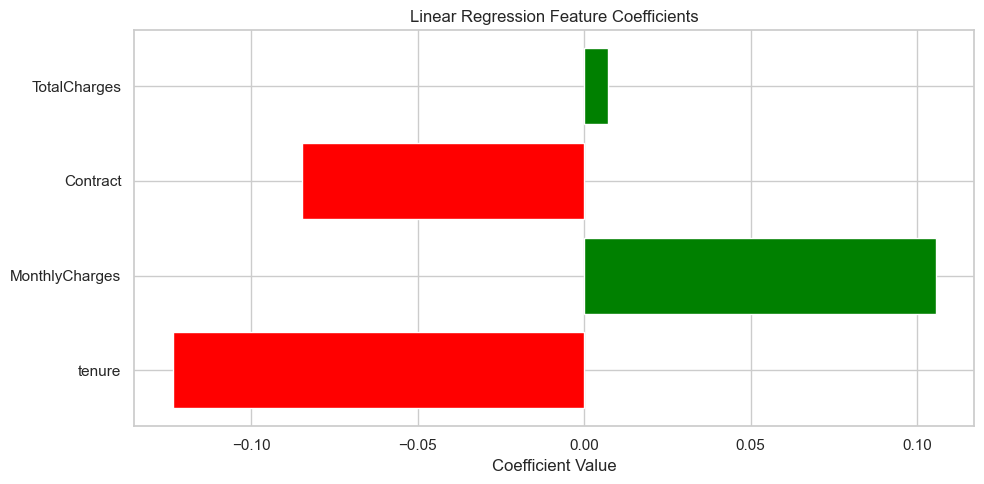


Predicted vs Actual (first 20 test samples):
    Actual  Predicted
0        1   0.346733
1        0   0.163665
2        0  -0.139944
3        1   0.541854
4        0  -0.095567
5        1   0.247952
6        0   0.213546
7        0  -0.039804
8        1   0.087483
9        1   0.325672
10       0   0.329856
11       0   0.390353
12       0   0.196031
13       1   0.469861
14       0   0.264053
15       1   0.560138
16       1   0.408959
17       1   0.518358
18       0   0.393365
19       1   0.466249


In [32]:
# Multiple Linear Regression with all selected features
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

print("\nMultiple Linear Regression Analysis with All Features:")
print("=" * 60)

# Prepare features for regression (4-variable linear regression)
lr_features = ['tenure', 'Contract', 'MonthlyCharges', 'TotalCharges']
X_reg = X[lr_features].copy()

# Encode categorical variables
X_reg_encoded = X_reg.copy()
for col in X_reg_encoded.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X_reg_encoded[col] = le.fit_transform(X_reg_encoded[col])

# Handle missing values
X_reg_encoded = X_reg_encoded.fillna(X_reg_encoded.mean())

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reg_encoded)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.25, random_state=42)

# Fit multiple linear regression model
mlr = LinearRegression()
mlr.fit(X_train, y_train)

# Make predictions
y_pred_train = mlr.predict(X_train)
y_pred_test = mlr.predict(X_test)

# Calculate metrics
train_r2 = mlr.score(X_train, y_train)
test_r2 = mlr.score(X_test, y_test)
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)

print("\nModel Performance:")
print(f"  Training R²: {train_r2:.4f}")
print(f"  Testing R²: {test_r2:.4f}")
print(f"  Training RMSE: {train_rmse:.4f}")
print(f"  Testing RMSE: {test_rmse:.4f}")
print(f"  Training MAE: {train_mae:.4f}")
print(f"  Testing MAE: {test_mae:.4f}")

print("\nFeature Coefficients (sorted by importance):")
coef_df = pd.DataFrame({
    'Feature': lr_features,
    'Coefficient': mlr.coef_
})
coef_df['Abs_Coefficient'] = abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False)
print(coef_df[['Feature', 'Coefficient']])

print(f"\nIntercept: {mlr.intercept_:.4f}")

# Visualize coefficients
plt.figure(figsize=(10, 5))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=['green' if x > 0 else 'red' for x in coef_df['Coefficient']])
plt.xlabel('Coefficient Value')
plt.title('Linear Regression Feature Coefficients')
plt.tight_layout()
plt.show()

print("\nPredicted vs Actual (first 20 test samples):")
comparison_df = pd.DataFrame({
    'Actual': y_test[:20].values,
    'Predicted': y_pred_test[:20]
})
print(comparison_df)

In [34]:
# Fix TotalCharges
df_IBM["TotalCharges"] = pd.to_numeric(df_IBM["TotalCharges"], errors="coerce")
df_IBM["TotalCharges"].fillna(df_IBM["TotalCharges"].median(), inplace=True)

# Convert Churn to numeric
df_IBM["Churn"] = df_IBM["Churn"].map({"Yes": 1, "No": 0})

# Split groups
churn_yes = df_IBM[df_IBM["Churn"] == 1]
churn_no = df_IBM[df_IBM["Churn"] == 0]

from scipy.stats import ttest_ind, chi2_contingency, mannwhitneyu

# Helper function
def interpret(p):
    return "Significant ✅ (affects churn)" if p < 0.05 else "Not Significant ❌"

# TENURE
print("\n--- Tenure ---")
stat, p = ttest_ind(churn_yes["tenure"], churn_no["tenure"], equal_var=False)
print("p-value:", p, "|", interpret(p))

# MONTHLY CHARGES
print("\n--- MonthlyCharges ---")
stat, p = ttest_ind(churn_yes["MonthlyCharges"], churn_no["MonthlyCharges"], equal_var=False)
print("p-value:", p, "|", interpret(p))

# TOTAL CHARGES
print("\n--- TotalCharges ---")
stat, p = mannwhitneyu(churn_yes["TotalCharges"], churn_no["TotalCharges"])
print("p-value:", p, "|", interpret(p))

# CONTRACT
print("\n--- Contract ---")
contingency = pd.crosstab(df_IBM["Contract"], df_IBM["Churn"])
stat, p, dof, expected = chi2_contingency(contingency)
print("p-value:", p, "|", interpret(p))

# INTERNET SERVICE
print("\n--- InternetService ---")
contingency = pd.crosstab(df_IBM["InternetService"], df_IBM["Churn"])
stat, p, dof, expected = chi2_contingency(contingency)
print("p-value:", p, "|", interpret(p))


--- Tenure ---
p-value: 1.1954945472607151e-232 | Significant ✅ (affects churn)

--- MonthlyCharges ---
p-value: 8.59244933154705e-73 | Significant ✅ (affects churn)

--- TotalCharges ---
p-value: 1.8396234229657706e-84 | Significant ✅ (affects churn)

--- Contract ---
p-value: 5.863038300673391e-258 | Significant ✅ (affects churn)

--- InternetService ---
p-value: 9.571788222840544e-160 | Significant ✅ (affects churn)


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20428\188286753.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_IBM["TotalCharges"].fillna(df_IBM["TotalCharges"].median(), inplace=True)
